# Monthly Milk Production Forecasting Using RNN, LSTM, and GRU Deep Learning Models


**Step 1: Identify Business Problem**

*Business Problem *: The dairy business wants to forecast future monthly milk production so that it can plan inventory, storage, transportation, workforce allocation, and supply chain operations efficiently.

**Step 2: Define Objective**

*Objective *:The objective of this project is to build RNN, LSTM, and GRU models to forecast future monthly milk production and compare their performance to identify the best forecasting model.

**Exploratory Data Analysis (EDA)**

In [ ]:
##loading dataset
import pandas as pd

df = pd.read_csv('monthly_milk_production.csv')
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [ ]:
df.shape

(168, 2)

In [ ]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [ ]:
##missing values
df.isnull().sum()

,0
Date,0
Production,0


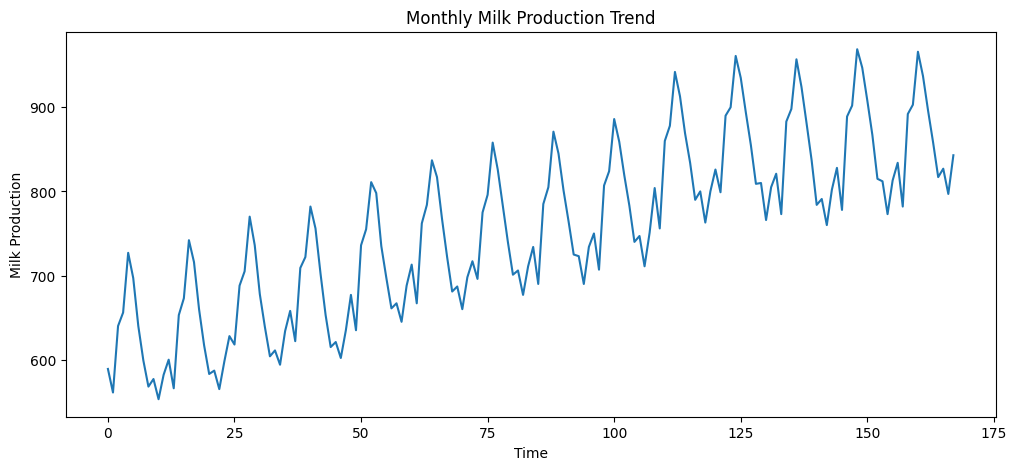

In [ ]:
##trend visulaization
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df.iloc[:,1])
plt.title("Monthly Milk Production Trend")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.show()

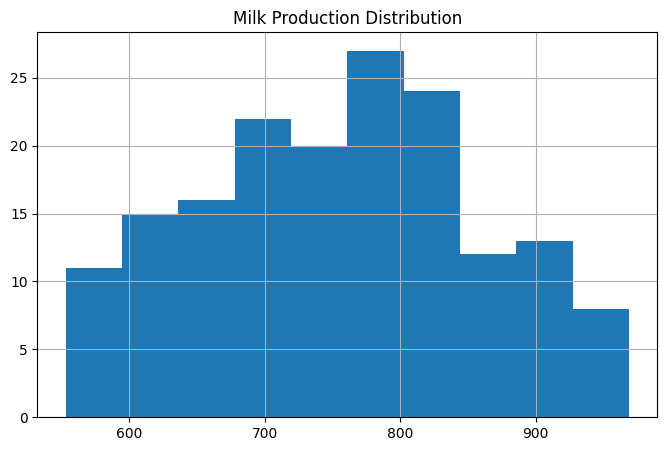

In [ ]:
##histogram
df.iloc[:,1].hist(figsize=(8,5))
plt.title("Milk Production Distribution")
plt.show()

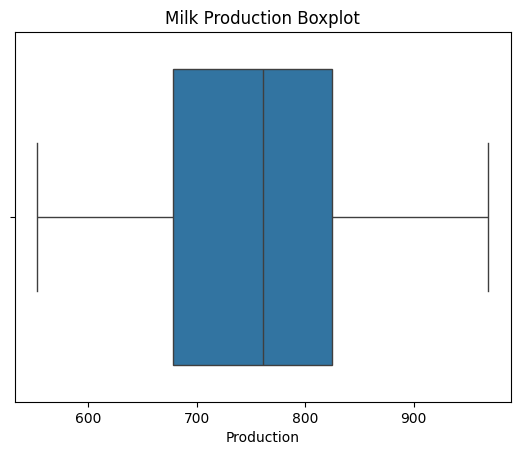

In [ ]:
##boxplot
import seaborn as sns

sns.boxplot(x=df.iloc[:,1])
plt.title("Milk Production Boxplot")
plt.show()

**EDA Interpretation** : The time series shows seasonal fluctuations and trend patterns in milk production. Histograms and boxplots help understand data distribution and identify potential outliers.

**2.Data Preparation for Deep Learning**

In [ ]:
##scaling data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    df.iloc[:,1].values.reshape(-1,1)
)

In [ ]:
#create sequences
import numpy as np

def create_sequences(data, window_size):

    X = []
    y = []

    for i in range(len(data)-window_size):

        X.append(data[i:i+window_size])
        y.append(data[i+window_size])

    return np.array(X), np.array(y)

window_size = 12

X,y = create_sequences(scaled_data,window_size)

In [ ]:
#train-test split
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [ ]:
##reshape data
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

**3.Model Building**

In [ ]:
#Building Basic RNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,SimpleRNN

rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        50,
        input_shape=(window_size,1)
    )
)

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3852
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0376 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0253 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0177 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0090 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0073 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0051 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0042 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0037 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0027 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0027 
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023 
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023 
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0022 
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/st

In [ ]:
#Building LSTM Model
from tensorflow.keras.layers import LSTM

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        50,
        input_shape=(window_size,1)
    )
)

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1540
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0357 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0362 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0270 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0268 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0255 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0248 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0245 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0240 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0240 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0234 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0233 
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0230 
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0230 
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0223 
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━━━━

In [ ]:
#Building GRU Model
from tensorflow.keras.layers import GRU

gru_model = Sequential()

gru_model.add(
    GRU(
        50,
        input_shape=(window_size,1)
    )
)

gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

gru_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2123
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0789 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0312 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0356 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0281 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0271 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0267
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0251 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0248 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0241
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0234 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0230 
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0222
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0218
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0213
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/s

**4.Model Evaluation**

In [ ]:
#Predictions
rnn_pred = rnn_model.predict(X_test)

lstm_pred = lstm_model.predict(X_test)

gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


In [ ]:
#Metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

def evaluate(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    )

    return rmse,mae,mape

In [ ]:
print("RNN:",evaluate(y_test,rnn_pred))

print("LSTM:",evaluate(y_test,lstm_pred))

print("GRU:",evaluate(y_test,gru_pred))

RNN: (np.float64(0.042601365038717046), 0.03635755338920998, 0.05176034855262317)
LSTM: (np.float64(0.06666300319274944), 0.0563392389852267, 0.08118045562215112)
GRU: (np.float64(0.07582245017195212), 0.062023881679544056, 0.09080021849944468)


In [ ]:
#Comparative Analysis
comparison = pd.DataFrame({

    'Model':['RNN','LSTM','GRU'],

    'RMSE':[
        evaluate(y_test,rnn_pred)[0],
        evaluate(y_test,lstm_pred)[0],
        evaluate(y_test,gru_pred)[0]
    ],

    'MAE':[
        evaluate(y_test,rnn_pred)[1],
        evaluate(y_test,lstm_pred)[1],
        evaluate(y_test,gru_pred)[1]
    ],

    'MAPE':[
        evaluate(y_test,rnn_pred)[2],
        evaluate(y_test,lstm_pred)[2],
        evaluate(y_test,gru_pred)[2]
    ]
})

comparison

,Model,RMSE,MAE,MAPE
0,RNN,0.042601,0.036358,0.05176
1,LSTM,0.066663,0.056339,0.08118
2,GRU,0.075822,0.062024,0.09080


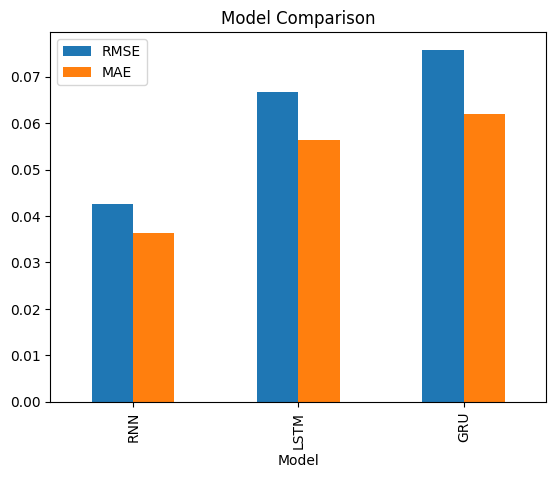

In [ ]:
comparison.plot(
    x='Model',
    y=['RMSE','MAE'],
    kind='bar'
)

plt.title("Model Comparison")
plt.show()

**5.Prediction and Visualization**

In [ ]:
#Forecast Next 12 Months
future_predictions = []

current_sequence = X_test[-1]

for i in range(12):

    pred = lstm_model.predict(
        current_sequence.reshape(
            1,
            window_size,
            1
        )
    )

    future_predictions.append(pred[0,0])

    current_sequence = np.append(
        current_sequence[1:],
        pred
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


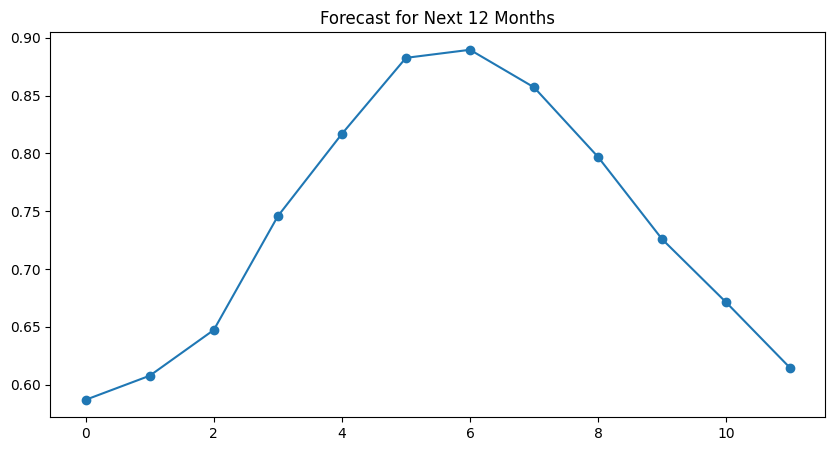

In [ ]:
#Plot Forecast
plt.figure(figsize=(10,5))

plt.plot(
    future_predictions,
    marker='o'
)

plt.title(
    "Forecast for Next 12 Months"
)

plt.show()

**6.Plot Forecast**

The forecasting model helps the dairy business estimate future milk production and make informed decisions regarding inventory, storage, transportation, workforce management, and supply chain planning. Accurate forecasts reduce operational risks and improve resource utilization.